# 04 — RSNA Preprocessing

Ce notebook montre comment charger et prétraiter des images thoraciques pour le pipeline VLM du projet.

Objectifs :
- vérifier si le dataset RSNA Pneumonia est disponible localement ;
- utiliser les vraies images RSNA si elles existent ;
- sinon, basculer automatiquement vers les images synthétiques du projet ;
- charger une image ;
- appliquer le prétraitement standard ;
- tester le pipeline sur plusieurs images.

> Important : ce notebook ne réalise pas de diagnostic médical. Il sert uniquement à vérifier le pipeline technique du projet.

## 1. Imports et configuration du projet

On ajoute la racine du repo au `sys.path` pour pouvoir importer les fonctions du dossier `src/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/33782/PycharmProjects/Assistant_Radiologue_Virtuel')

## 2. Import des fonctions de prétraitement

Ces fonctions viennent de `src/preprocessing.py`.

In [2]:
from src.preprocessing import (
    DEFAULT_IMAGE_SIZE,
    DEFAULT_RSNA_DIR,
    DEFAULT_SYNTHETIC_DIR,
    basic_quality_flag,
    find_image_files,
    get_demo_images,
    is_rsna_available,
    load_image,
    preprocess_image,
)

print('Image size:', DEFAULT_IMAGE_SIZE)
print('RSNA dir:', DEFAULT_RSNA_DIR)
print('Synthetic dir:', DEFAULT_SYNTHETIC_DIR)

Image size: (512, 512)
RSNA dir: C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna
Synthetic dir: C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\sample_images


## 3. Vérification de la présence du dataset RSNA

Le vrai dataset RSNA ne doit pas être versionné dans GitHub. Il doit être téléchargé localement, par exemple dans `data/raw/rsna/`.

In [3]:
rsna_available = is_rsna_available(DEFAULT_RSNA_DIR)

if rsna_available:
    print('Dataset RSNA détecté localement.')
else:
    print('Dataset RSNA non détecté. Le notebook utilisera les images synthétiques de démonstration.')

Dataset RSNA détecté localement.


## 4. Sélection des images de démonstration

Si RSNA est présent, on prend quelques images RSNA. Sinon, on utilise `data/sample_images/`.

In [4]:
demo_images = get_demo_images(limit=5)

print(f'{len(demo_images)} image(s) trouvée(s).')
for path in demo_images:
    print('-', path)

5 image(s) trouvée(s).
- C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm
- C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm
- C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm
- C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\000e3a7d-c0ca-4349-bb26-5af2d8993c3d.dcm
- C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\00100a24-854d-423d-a092-edcf6179e061.dcm


## 5. Chargement d'une image

On charge une première image avec `load_image()`. La fonction renvoie une image PIL en RGB, redimensionnée.

Image sélectionnée : C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\raw\rsna\rsna-pneumonia-detection-challenge\stage_2_test_images\0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm
Format PIL : <class 'PIL.Image.Image'>
Mode : RGB
Taille : (512, 512)
Quality flag : good


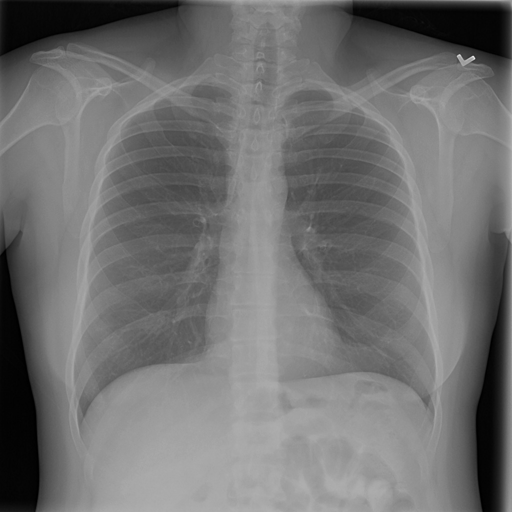

In [6]:
if not demo_images:
    raise FileNotFoundError(
        'Aucune image disponible. Vérifie la présence de data/sample_images/ ou du dataset RSNA local.'
    )

sample_path = demo_images[0]
img = load_image(sample_path)

print('Image sélectionnée :', sample_path)
print('Format PIL :', type(img))
print('Mode :', img.mode)
print('Taille :', img.size)
print('Quality flag :', basic_quality_flag(sample_path))

img

## 6. Prétraitement pour le pipeline VLM

`preprocess_image()` renvoie par défaut une image PIL RGB. Avec `as_numpy=True`, elle peut aussi renvoyer un tableau normalisé entre 0 et 1.

Image prétraitée :
Mode : RGB
Taille : (512, 512)


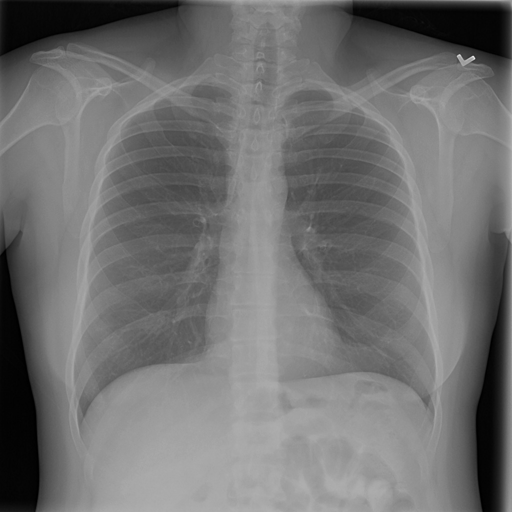

In [7]:
processed_img = preprocess_image(sample_path)

print('Image prétraitée :')
print('Mode :', processed_img.mode)
print('Taille :', processed_img.size)

processed_img

## 7. Version NumPy normalisée, optionnelle

Cette étape est utile si un modèle ou un pipeline attend directement un tableau numérique.

In [8]:
try:
    arr = preprocess_image(sample_path, as_numpy=True)
    print('Shape :', arr.shape)
    print('Dtype :', arr.dtype)
    print('Min :', arr.min())
    print('Max :', arr.max())
except ImportError as exc:
    print('NumPy non disponible dans cet environnement :', exc)

Shape : (512, 512, 3)
Dtype : float32
Min : 0.0
Max : 0.90588236


In [9]:
# Nouvelle cellule : Conversion massive en PNG pour MedGemma
from tqdm import tqdm
import os
import cv2

# Définition du dossier de sortie
output_dir = PROJECT_ROOT / "data" / "processed" / "rsna_png"
output_dir.mkdir(parents=True, exist_ok=True)

# Conversion des images de démonstration (ou de tout le dataset si tu le souhaites)
print(f"Conversion en cours vers : {output_dir}")
for path in tqdm(demo_images):
    # Utilisation de ton pipeline existant (preprocess_image)
    img_pil = preprocess_image(path)
    
    # Construction du nom de fichier final
    save_path = output_dir / f"{path.stem}.png"
    
    # Sauvegarde au format PNG
    img_pil.save(save_path)

print("Conversion terminée avec succès.")

Conversion en cours vers : C:\Users\33782\PycharmProjects\Assistant_Radiologue_Virtuel\data\processed\rsna_png


100%|██████████| 5/5 [00:00<00:00,  5.98it/s]

Conversion terminée avec succès.


## 8. Test du pipeline sur plusieurs images

On vérifie que chaque image peut être chargée et prétraitée sans erreur.

In [10]:
results = []

for path in demo_images:
    try:
        image = preprocess_image(path)
        results.append({
            'path': str(path),
            'status': 'ok',
            'mode': image.mode,
            'size': image.size,
            'quality': basic_quality_flag(path),
        })
    except Exception as exc:
        results.append({
            'path': str(path),
            'status': 'error',
            'error': str(exc),
        })

results

[{'path': 'C:\\Users\\33782\\PycharmProjects\\Assistant_Radiologue_Virtuel\\data\\raw\\rsna\\rsna-pneumonia-detection-challenge\\stage_2_test_images\\0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm',
  'status': 'ok',
  'mode': 'RGB',
  'size': (512, 512),
  'quality': 'good'},
 {'path': 'C:\\Users\\33782\\PycharmProjects\\Assistant_Radiologue_Virtuel\\data\\raw\\rsna\\rsna-pneumonia-detection-challenge\\stage_2_test_images\\0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm',
  'status': 'ok',
  'mode': 'RGB',
  'size': (512, 512),
  'quality': 'good'},
 {'path': 'C:\\Users\\33782\\PycharmProjects\\Assistant_Radiologue_Virtuel\\data\\raw\\rsna\\rsna-pneumonia-detection-challenge\\stage_2_test_images\\000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm',
  'status': 'ok',
  'mode': 'RGB',
  'size': (512, 512),
  'quality': 'good'},
 {'path': 'C:\\Users\\33782\\PycharmProjects\\Assistant_Radiologue_Virtuel\\data\\raw\\rsna\\rsna-pneumonia-detection-challenge\\stage_2_test_images\\000e3a7d-c0ca-4349-bb26-5af2d8993c

## 9. Résumé simple du test

On transforme les résultats en tableau si pandas est disponible.

In [11]:
try:
    import pandas as pd
    display(pd.DataFrame(results))
except ImportError:
    for item in results:
        print(item)

C:\Users\33782\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,path,status,mode,size,quality
0,C:\Users\33782\PycharmProjects\Assistant_Radio...,ok,RGB,"(512, 512)",good
1,C:\Users\33782\PycharmProjects\Assistant_Radio...,ok,RGB,"(512, 512)",good
2,C:\Users\33782\PycharmProjects\Assistant_Radio...,ok,RGB,"(512, 512)",good
3,C:\Users\33782\PycharmProjects\Assistant_Radio...,ok,RGB,"(512, 512)",good
4,C:\Users\33782\PycharmProjects\Assistant_Radio...,ok,RGB,"(512, 512)",good


## 10. Conclusion

Ce notebook valide le pipeline de prétraitement :

- les images synthétiques restent utilisables pour les tests rapides ;
- les images RSNA peuvent être chargées localement si elles sont disponibles ;
- les images sont converties en RGB et redimensionnées en `512x512` ;
- le vrai dataset RSNA n'est pas stocké dans GitHub.

Pour utiliser RSNA, télécharger les données localement avec le script `data/download_rsna.py`, puis relancer ce notebook.